In [1]:
from datasets import load_dataset

ds = load_dataset("lance-format/stanford-cars-lance", split="train", cache_dir="./Data/Datasets")
split = ds.train_test_split(test_size=0.10, seed=42)

train_ds = split["train"]
val_ds = split["test"]

print("Train:", len(train_ds))
print("Validation:", len(val_ds))

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Train: 7329
Validation: 815


In [3]:
from Dataloader import TTIDataset
from Token.TTI_Tokenizer import TTITokenizer

tokenizer = TTITokenizer("Token/bpe_tokenizer.json")

train_dataset = TTIDataset(train_ds,tokenizer)
val_dataset = TTIDataset(val_ds,tokenizer)

In [ ]:
from Upscalar.Upscaler_dataset import UpscalerDataset
from torch.utils.data import DataLoader

upscale_dataset = UpscalerDataset(train_ds)
upscale_loader = DataLoader(upscale_dataset,batch_size=16,shuffle=True,num_workers=2,pin_memory=True)

batch = next(iter(upscale_loader))

print("LR:", batch["lr"].shape)
print("HR:", batch["hr"].shape)

LR: torch.Size([16, 3, 64, 64])
HR: torch.Size([16, 3, 256, 256])


In [ ]:
import torch
import torch.nn.functional as F
from Upscalar.Upscaler import Upscaler

device = "cuda" if torch.cuda.is_available() else "cpu"

upscaler = Upscaler().to(device)
optimizer = torch.optim.AdamW(upscaler.parameters(),lr=2e-4,weight_decay=1e-4)

EPOCHS = 50

In [ ]:
import os
import torch

CHECKPOINT_PATH = "checkpoints/upscaler.pt"
os.makedirs("checkpoints", exist_ok=True)

start_epoch = 0

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    upscaler.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    print(f"Resuming from epoch {start_epoch + 1} | Loss: {checkpoint['loss']:.6f}")

for epoch in range(start_epoch, EPOCHS):
    upscaler.train()
    total_loss = 0.0

    for batch in upscale_loader:
        lr = batch["lr"].to(device, non_blocking=True)
        hr = batch["hr"].to(device, non_blocking=True)

        predicted = upscaler(lr)

        loss = F.l1_loss(predicted, hr)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(upscale_loader)

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": upscaler.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": avg_loss
    }, CHECKPOINT_PATH)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

Epoch 1/50 | Loss: 0.096736
Epoch 2/50 | Loss: 0.065837
Epoch 3/50 | Loss: 0.061518
Epoch 4/50 | Loss: 0.059075
Epoch 5/50 | Loss: 0.057899
Epoch 6/50 | Loss: 0.055929
Epoch 7/50 | Loss: 0.054876
Epoch 8/50 | Loss: 0.053972
Epoch 9/50 | Loss: 0.053685
Epoch 10/50 | Loss: 0.052909
Epoch 11/50 | Loss: 0.052656
Epoch 12/50 | Loss: 0.051987
Epoch 13/50 | Loss: 0.051791
Epoch 14/50 | Loss: 0.051046
Epoch 15/50 | Loss: 0.050757
Epoch 16/50 | Loss: 0.050791
Epoch 17/50 | Loss: 0.050180
Epoch 18/50 | Loss: 0.050055
Epoch 19/50 | Loss: 0.049888
Epoch 20/50 | Loss: 0.049539
Epoch 21/50 | Loss: 0.049478
Epoch 22/50 | Loss: 0.048945
Epoch 23/50 | Loss: 0.049018
Epoch 24/50 | Loss: 0.048802
Epoch 25/50 | Loss: 0.048544
Epoch 26/50 | Loss: 0.048721
Epoch 27/50 | Loss: 0.048137


KeyboardInterrupt: 

In [8]:
avg_loss = total_loss / len(upscale_loader)
torch.save({"epoch": epoch + 1,"model_state_dict": upscaler.state_dict(),"optimizer_state_dict": optimizer.state_dict(),"loss": avg_loss}, "checkpoints/upscaler.pt")

print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

Epoch 28/50 | Loss: 0.018617


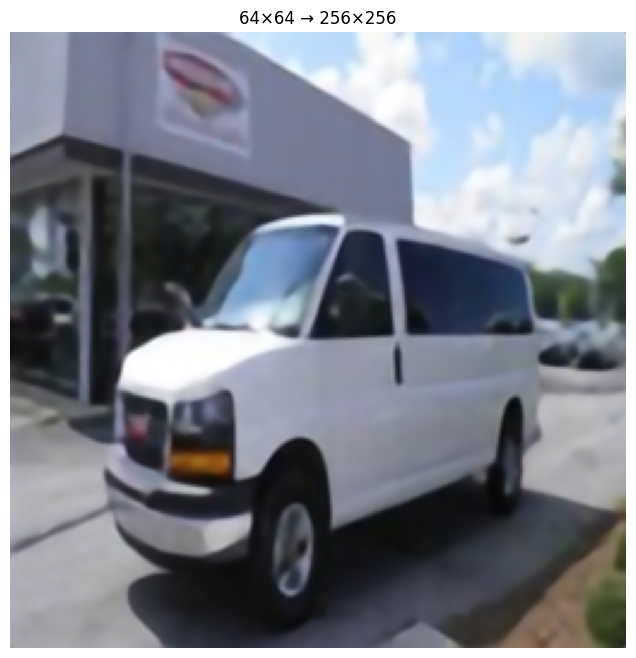

In [10]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def upscale_image(image, upscaler, device):
    upscaler.eval()
    if image.dim() == 3:
        image = image.unsqueeze(0)
    image = image.to(device)
    output = upscaler(image)
    output = ((output.clamp(-1, 1) + 1) / 2).clamp(0, 1)
    return output[0].permute(1, 2, 0).cpu()

sample = next(iter(upscale_loader))
lr = sample["lr"][6]
upscaled = upscale_image(lr, upscaler, device)

plt.figure(figsize=(8, 8))
plt.imshow(upscaled)
plt.axis("off")
plt.title("64×64 → 256×256")
plt.show()